# Ridge / Lasso baselines + learning curves

Notebook này dùng cùng file processed data với `linear_regression.ipynb`, sau đó test `Ridge` và `Lasso` với vài giá trị `alpha`, chọn model tốt nhất theo validation RMSE, rồi plot learning curve.

In [1]:
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)

In [2]:
DATA_PATH = Path('../processed_data/model_ready/gdsc2_lgbm_style_data.npz')
METADATA_PATH = Path('../processed_data/model_ready/artifacts/gdsc2_lgbm_style_metadata.json')
OUTPUT_DIR = Path('../models/ridge_lasso_baselines')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

loaded = np.load(DATA_PATH)
X_train = loaded['X_train']
y_train = loaded['y_train']
X_val = loaded['X_val']
y_val = loaded['y_val']
X_test = loaded['X_test']
y_test = loaded['y_test']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)
metadata

X_train: (65239, 1477) y_train: (65239,)
X_val:   (9233, 1477) y_val:   (9233,)
X_test:  (18231, 1477) y_test:  (18231,)


{'dataset': 'GDSC2',
 'split_method': 'cold_split by Cell Line_ID',
 'random_state': 42,
 'drug_feature': 'Morgan fingerprint 1024 bits',
 'cell_feature': 'StandardScaler + PCA fitted on train cell lines only',
 'cell_pca_components': 453,
 'X_train_shape': [65239, 1477],
 'X_val_shape': [9233, 1477],
 'X_test_shape': [18231, 1477],
 'saved_npz': '../processed_data/model_ready/gdsc2_lgbm_style_data.npz'}

In [3]:
def safe_corr(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def compute_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': safe_corr(y_true, y_pred),
    }


def fit_eval_model(model_name, model):
    start = time.time()
    model.fit(X_train, y_train)
    fit_seconds = time.time() - start

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    row = {
        'model': model_name,
        'fit_seconds': fit_seconds,
        **{f'val_{k}': v for k, v in compute_metrics(y_val, val_pred).items()},
        **{f'test_{k}': v for k, v in compute_metrics(y_test, test_pred).items()},
    }
    return row, model, val_pred, test_pred

## 1. Alpha sweep

`Ridge` thường là baseline quan trọng ở đây vì dữ liệu nhiều feature và có thể multicollinearity. `Lasso` có thể chậm hơn, nên nếu chạy lâu quá có thể giảm list `LASSO_ALPHAS` hoặc tăng `tol`.

In [4]:
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
LASSO_ALPHAS = [0.0001, 0.001, 0.01, 0.1, 1.0]

candidate_models = []
for alpha in RIDGE_ALPHAS:
    candidate_models.append((f'ridge_alpha_{alpha:g}', Ridge(alpha=alpha)))

for alpha in LASSO_ALPHAS:
    candidate_models.append((
        f'lasso_alpha_{alpha:g}',
        Lasso(alpha=alpha, max_iter=5000, tol=1e-3, selection='random', random_state=42),
    ))

rows = []
fitted_models = {}
predictions = {}

for model_name, model in candidate_models:
    print('Fitting', model_name)
    row, fitted_model, val_pred, test_pred = fit_eval_model(model_name, model)
    rows.append(row)
    fitted_models[model_name] = fitted_model
    predictions[model_name] = {'val': val_pred, 'test': test_pred}

results_df = pd.DataFrame(rows).sort_values('val_rmse')
display(results_df.round(4))
results_df.to_csv(OUTPUT_DIR / 'ridge_lasso_alpha_sweep.csv', index=False)

Fitting ridge_alpha_0.01
Fitting ridge_alpha_0.1
Fitting ridge_alpha_1


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.196184759195035e-10.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Fitting ridge_alpha_10


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.2754313684697536e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Fitting ridge_alpha_100


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.329481377382763e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Fitting ridge_alpha_1000
Fitting lasso_alpha_0.0001
Fitting lasso_alpha_0.001
Fitting lasso_alpha_0.01
Fitting lasso_alpha_0.1
Fitting lasso_alpha_1


,model,fit_seconds,val_rmse,val_mae,val_r2,val_pearson,test_rmse,test_mae,test_r2,test_pearson
4,ridge_alpha_100,0.7269,1.3133,0.9936,0.7584,0.8728,1.3606,1.0301,0.7497,0.8660
6,lasso_alpha_0.0001,53.8881,1.3133,0.9930,0.7584,0.8728,1.3603,1.0297,0.7498,0.8661
3,ridge_alpha_10,0.6356,1.3133,0.9930,0.7584,0.8728,1.3603,1.0297,0.7498,0.8661
2,ridge_alpha_1,0.7383,1.3134,0.9930,0.7584,0.8728,1.3603,1.0296,0.7498,0.8661
1,ridge_alpha_0.1,11.6446,1.3134,0.9929,0.7584,0.8728,1.3603,1.0296,0.7498,0.8661
0,ridge_alpha_0.01,18.5865,1.3134,0.9929,0.7584,0.8728,1.3603,1.0296,0.7498,0.8661
7,lasso_alpha_0.001,7.1463,1.3138,0.9946,0.7582,0.8727,1.3618,1.0312,0.7492,0.8658
5,ridge_alpha_1000,0.7106,1.3220,1.0066,0.7552,0.8714,1.3727,1.0432,0.7452,0.8640
8,lasso_alpha_0.01,1.8202,1.3683,1.0552,0.7377,0.8636,1.4246,1.0920,0.7256,0.8548
9,lasso_alpha_0.1,0.6114,2.1417,1.6873,0.3574,0.6412,2.2083,1.7111,0.3406,0.6186


In [5]:
best_by_family = {}
for family in ['ridge', 'lasso']:
    family_df = results_df[results_df['model'].str.startswith(family)]
    best_name = family_df.iloc[0]['model']
    best_by_family[family] = best_name
    joblib.dump(fitted_models[best_name], OUTPUT_DIR / f'best_{family}.joblib')
    np.save(OUTPUT_DIR / f'best_{family}_val_pred.npy', predictions[best_name]['val'])
    np.save(OUTPUT_DIR / f'best_{family}_test_pred.npy', predictions[best_name]['test'])

best_by_family

{'ridge': 'ridge_alpha_100', 'lasso': 'lasso_alpha_0.0001'}

## 2. Learning curves

Các subset được lấy theo một permutation cố định, nên điểm 20% chứa toàn bộ điểm 10%, điểm 40% chứa toàn bộ điểm 20%, ...

In [6]:
def run_learning_curve(model_name, base_model, train_fractions, random_state=42):
    rng = np.random.default_rng(random_state)
    n_train = len(X_train)
    perm = rng.permutation(n_train)
    rows = []

    for fraction in train_fractions:
        sample_size = max(10, int(n_train * fraction))
        sample_idx = perm[:sample_size]

        model = clone(base_model)
        start = time.time()
        model.fit(X_train[sample_idx], y_train[sample_idx])
        fit_seconds = time.time() - start

        train_pred = model.predict(X_train[sample_idx])
        val_pred = model.predict(X_val)

        train_metrics = compute_metrics(y_train[sample_idx], train_pred)
        val_metrics = compute_metrics(y_val, val_pred)

        rows.append({
            'model': model_name,
            'train_fraction': fraction,
            'train_size': sample_size,
            'fit_seconds': fit_seconds,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}': v for k, v in val_metrics.items()},
        })

    return pd.DataFrame(rows)


train_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
learning_curve_parts = []

for family, best_name in best_by_family.items():
    print('Learning curve for', best_name)
    learning_curve_parts.append(
        run_learning_curve(best_name, fitted_models[best_name], train_fractions)
    )

learning_curve_df = pd.concat(learning_curve_parts, ignore_index=True)
display(learning_curve_df.round(4))
learning_curve_df.to_csv(OUTPUT_DIR / 'ridge_lasso_learning_curves.csv', index=False)

Learning curve for ridge_alpha_100


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.135528955539485e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.329330742322782e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Learning curve for lasso_alpha_0.0001


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.937e+02, tolerance: 4.862e+01
  model = cd_fast.enet_coordinate_descent(


,model,train_fraction,train_size,fit_seconds,train_rmse,train_mae,train_r2,train_pearson,val_rmse,val_mae,val_r2,val_pearson
0,ridge_alpha_100,0.1,6523,0.1557,1.1554,0.8795,0.8209,0.9068,1.3519,1.0346,0.7440,0.8648
1,ridge_alpha_100,0.2,13047,0.1538,1.1643,0.8776,0.8154,0.9033,1.3253,1.0075,0.7539,0.8708
2,ridge_alpha_100,0.4,26095,0.3230,1.1783,0.8841,0.8114,0.9008,1.3159,0.9975,0.7574,0.8721
3,ridge_alpha_100,0.6,39143,0.4441,1.1900,0.8898,0.8085,0.8992,1.3120,0.9940,0.7589,0.8728
4,ridge_alpha_100,0.8,52191,0.5855,1.1921,0.8908,0.8080,0.8989,1.3131,0.9940,0.7585,0.8728
5,ridge_alpha_100,1.0,65239,0.7161,1.1975,0.8944,0.8072,0.8985,1.3133,0.9936,0.7584,0.8728
6,lasso_alpha_0.0001,0.1,6523,11.0076,1.1402,0.8622,0.8256,0.9086,1.3499,1.0248,0.7448,0.8652
7,lasso_alpha_0.0001,0.2,13047,17.6046,1.1598,0.8711,0.8169,0.9038,1.3242,1.0027,0.7544,0.8711
8,lasso_alpha_0.0001,0.4,26095,28.7493,1.1770,0.8819,0.8118,0.9010,1.3158,0.9955,0.7575,0.8722
9,lasso_alpha_0.0001,0.6,39143,34.3207,1.1894,0.8886,0.8087,0.8993,1.3124,0.9930,0.7587,0.8728


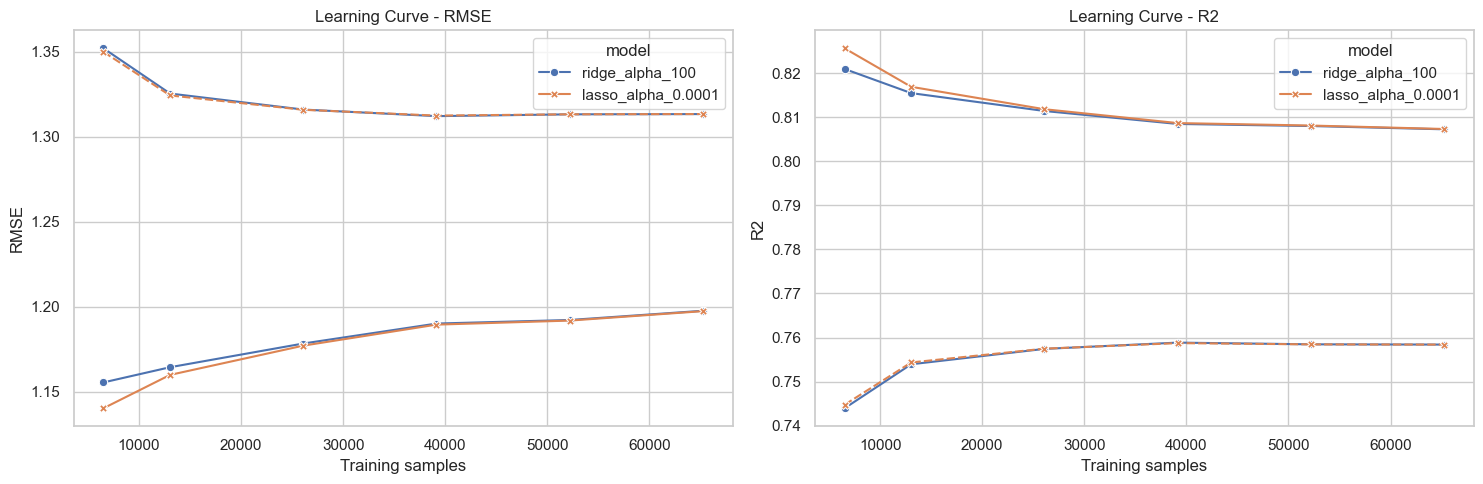

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='train_rmse',
    hue='model',
    style='model',
    markers=True,
    dashes=False,
    ax=axes[0],
)
sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='val_rmse',
    hue='model',
    style='model',
    markers=True,
    dashes=True,
    ax=axes[0],
    legend=False,
)
axes[0].set_title('Learning Curve - RMSE')
axes[0].set_xlabel('Training samples')
axes[0].set_ylabel('RMSE')

sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='train_r2',
    hue='model',
    style='model',
    markers=True,
    dashes=False,
    ax=axes[1],
)
sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='val_r2',
    hue='model',
    style='model',
    markers=True,
    dashes=True,
    ax=axes[1],
    legend=False,
)
axes[1].set_title('Learning Curve - R2')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('R2')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ridge_lasso_learning_curves.png', dpi=160, bbox_inches='tight')
plt.show()